In [1]:
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

eta = 1
    t     best ep phi  best ep phi_pi      best ep pi
    0           12/29           19/29           29/29
  0.5           21/29           21/29           28/29
    1           11/29           27/29           27/29
    2           29/29           28/29           20/29
    3           29/29           29/29           20/29
    4           29/29           27/29           28/29
    5           27/29           28/29           27/29
    6           26/29           28/29           29/29


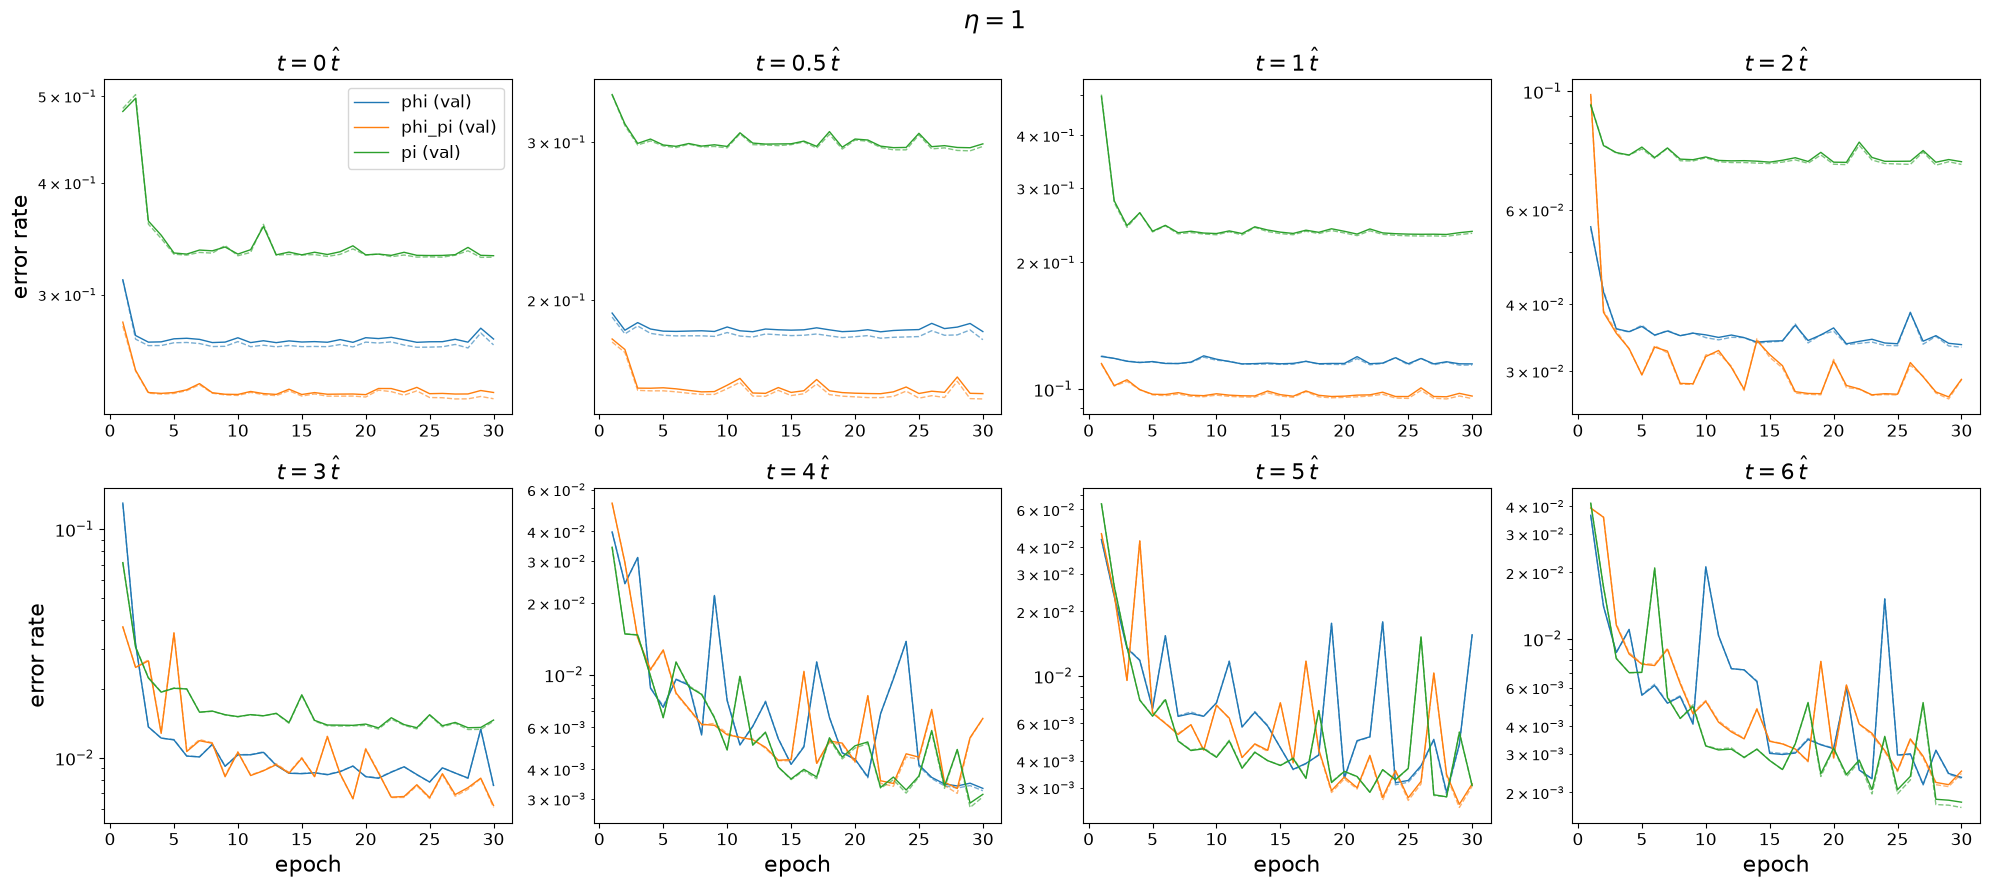

In [5]:
# ---- inputs ----
ETA      = "1"                                         # which damping run: "1", "0.3", "0.1"
RESULTS  = f"../results/momentum/eta{ETA}"
CHANNELS = [("phi", "C0"), ("phi_pi", "C1"), ("pi", "C2")]
FONTSIZE = 16

# load every run: runs[t][channels] = json contents
runs = {}
for f in glob.glob(f"{RESULTS}/t*.json"):              # t*.json skips corr.json
    r = json.load(open(f))
    runs.setdefault(r["t"], {})[r["channels"]] = r
times = sorted(runs)

# ---- table: best epoch by validation accuracy ----
print(f"eta = {ETA}")
print(f"{'t':>5}" + "".join(f"{'best ep ' + ch:>16}" for ch, _ in CHANNELS))
for t in times:
    row = []
    for ch, _ in CHANNELS:
        if ch in runs[t]:
            row.append(f"{int(np.argmax(np.array(runs[t][ch]['history'])[:, 3])):>13d}/29")
        else:
            row.append(f"{'-':>16}")
    print(f"{t:>5g}" + "".join(row))

# ---- learning curves ----
ncol = 4
nrow = int(np.ceil(len(times) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4.5 * nrow), squeeze=False)
for ax, t in zip(axes.ravel(), times):
    for ch, c in CHANNELS:
        if ch not in runs[t]:
            continue
        h  = np.array(runs[t][ch]["history"])            # train_loss, val_loss, train_acc, val_acc
        ep = np.arange(1, len(h) + 1)
        ax.semilogy(ep, 1 - h[:, 3], "-",  color=c, lw=1, label=f"{ch} (val)")
        ax.semilogy(ep, 1 - h[:, 2], "--", color=c, lw=1, alpha=0.6)
    ax.set_title(rf"$t = {t:g}\,\hat t$", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 4)
for ax in axes.ravel()[len(times):]:
    ax.axis("off")
for ax in axes[-1]:
    ax.set_xlabel("epoch", fontsize=FONTSIZE)
for ax in axes[:, 0]:
    ax.set_ylabel("error rate", fontsize=FONTSIZE)
axes[0, 0].legend(fontsize=FONTSIZE - 4)
fig.suptitle(rf"$\eta = {ETA}$", fontsize=FONTSIZE + 2)
plt.tight_layout()
plt.savefig(f"../figures/momentum/learning_curves_eta{ETA}.png", dpi=150)
plt.show()

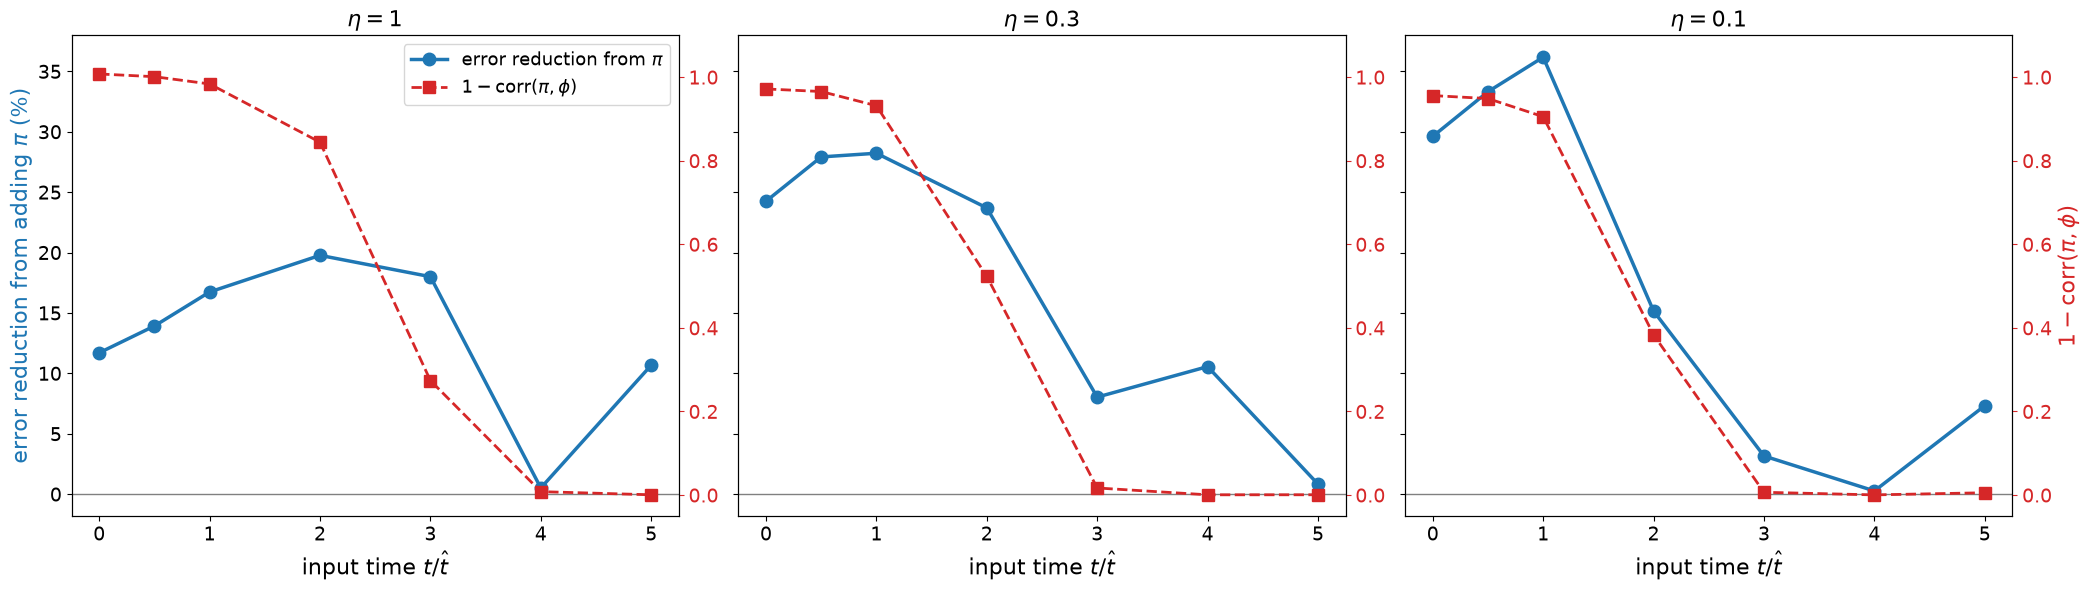

In [9]:
# ---- inputs ----
ETAS     = ["1", "0.3", "0.1"]
T_MAX    = 5                            # last time shown, units of t_hat
FONTSIZE = 16

fig, axes = plt.subplots(1, len(ETAS), figsize=(7 * len(ETAS), 6), sharey=True)

for ax, eta in zip(axes, ETAS):
    # momentum gain from the training results
    runs = {}
    for f in glob.glob(f"../results/momentum/eta{eta}/t*.json"):
        r = json.load(open(f))
        runs.setdefault(r["t"], {})[r["channels"]] = r
    ts   = sorted(t for t in runs if t <= T_MAX)
    gain = [100 * (1 - (1 - runs[t]["phi_pi"]["test_acc"]) / (1 - runs[t]["phi"]["test_acc"])) for t in ts]

    # fraction of pi not explained by phi
    c  = json.load(open(f"../results/momentum/eta{eta}/corr.json"))
    tc = np.array(c["times"])
    m  = tc <= T_MAX

    ax.plot(ts, gain, "o-", color="C0", ms=9, lw=2.5, label=r"error reduction from $\pi$")
    ax.axhline(0, color="grey", lw=1)
    ax.set_title(rf"$\eta = {eta}$", fontsize=FONTSIZE)
    ax.set_xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 2)

    ax2 = ax.twinx()
    ax2.plot(tc[m], 1 - np.array(c["corr"])[m], "s--", color="C3", ms=8, lw=2, label=r"$1 - \mathrm{corr}(\pi, \phi)$")
    ax2.set_ylim(-0.05, 1.1)
    ax2.tick_params(labelsize=FONTSIZE - 2, colors="C3")
    if eta == ETAS[-1]:
        ax2.set_ylabel(r"$1 - \mathrm{corr}(\pi, \phi)$", fontsize=FONTSIZE, color="C3")

axes[0].set_ylabel(r"error reduction from adding $\pi$ (%)", fontsize=FONTSIZE, color="C0")
h1, l1 = axes[0].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, fontsize=FONTSIZE - 3, loc="upper right")

plt.tight_layout()
plt.savefig("../figures/momentum/momentum_vs_correlation.png", dpi=150)
plt.show()

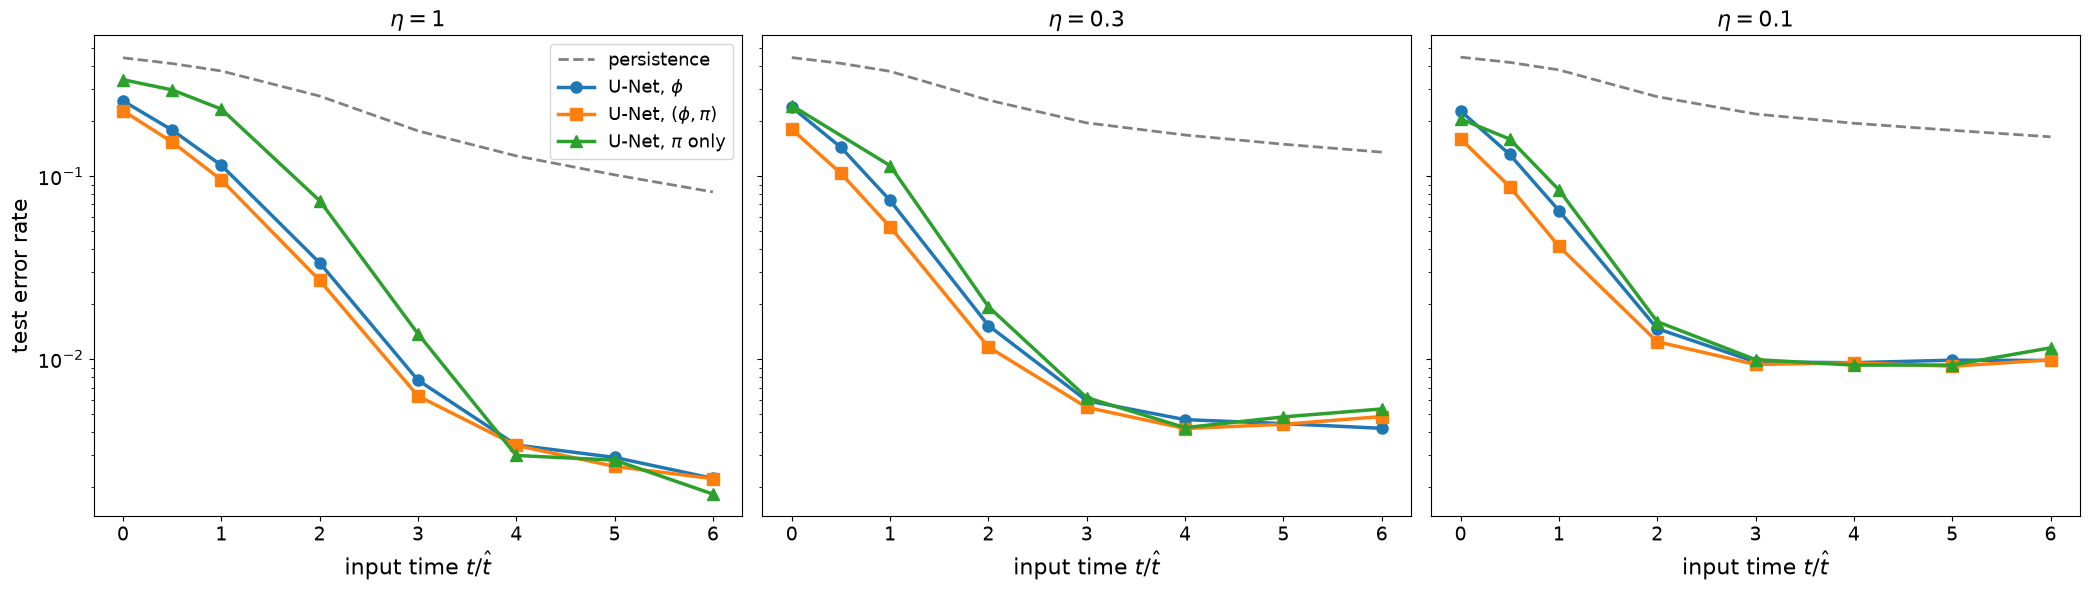

In [11]:
# ---- inputs ----
ETAS     = ["1", "0.3", "0.1"]
SKIP     = {("0.3", 0.5, "pi")}         # failed training runs to leave out: (eta, t, channels)
FONTSIZE = 16

styles = [("phi",    "o-", "C0", r"U-Net, $\phi$"),
          ("phi_pi", "s-", "C1", r"U-Net, $(\phi, \pi)$"),
          ("pi",     "^-", "C2", r"U-Net, $\pi$ only")]

fig, axes = plt.subplots(1, len(ETAS), figsize=(7 * len(ETAS), 6), sharey=True)

for ax, eta in zip(axes, ETAS):
    runs = {}
    for f in glob.glob(f"../results/momentum/eta{eta}/t*.json"):
        r = json.load(open(f))
        runs.setdefault(r["t"], {})[r["channels"]] = r
    ts = sorted(runs)

    ax.semilogy(ts, [1 - runs[t]["phi"]["baseline"] for t in ts], "--", color="grey", lw=2, label="persistence")
    for ch, style, c, lab in styles:
        tt = [t for t in ts if ch in runs[t] and (eta, t, ch) not in SKIP]
        ax.semilogy(tt, [1 - runs[t][ch]["test_acc"] for t in tt], style, color=c, lw=2.5, ms=8, label=lab)

    ax.set_title(rf"$\eta = {eta}$", fontsize=FONTSIZE)
    ax.set_xlabel(r"input time $t/\hat t$", fontsize=FONTSIZE)
    ax.tick_params(labelsize=FONTSIZE - 2)

axes[0].set_ylabel("test error rate", fontsize=FONTSIZE)
axes[0].legend(fontsize=FONTSIZE - 3)
plt.tight_layout()
plt.savefig("../figures/momentum/error_phi_vs_phipi.png", dpi=150)
plt.show()